<a href="https://colab.research.google.com/github/ParhamPishro/Flavonoid/blob/main/6%20Importance%20of%20Features/Exhaustive%20Feature%20Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

from sklearn.tree import DecisionTreeRegressor

from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS


Read Data

In [2]:
df = pd.read_excel("/content/FlavonoidData.xlsx")
df

,authors,flavonoid,cell line,time,dose,viability-mean,viability-error,viability-SD,viability-SE
0,Chen et al. 2017,Luteolin,KYSE30,48,10.0,77.272727,77.272727,0.001000,NaN
1,Chen et al. 2017,Luteolin,KYSE30,48,20.0,67.613636,67.613636,0.001000,NaN
2,Chen et al. 2017,Luteolin,KYSE30,48,40.0,47.159091,47.159091,0.001000,NaN
3,Chen et al. 2017,Luteolin,KYSE30,48,80.0,32.386364,32.386364,0.001000,NaN
4,Chen et al. 2017,Luteolin,KYSE30,72,10.0,69.886364,69.886364,0.001000,NaN
...,...,...,...,...,...,...,...,...,...
479,Zhu et al. 2016,Apigenin,KYSE150,24,20.0,88.407643,88.407643,0.001000,NaN
480,Zhu et al. 2016,Apigenin,KYSE150,24,40.0,78.980892,82.802548,3.821656,NaN
481,Zhu et al. 2016,Apigenin,KYSE150,24,60.0,67.261146,70.828025,3.566879,NaN
482,Zhu et al. 2016,Apigenin,KYSE150,24,80.0,45.350318,47.643312,2.292994,NaN


Discretized Data

In [3]:
df['v01'] = 1
df.loc[df['viability-mean']>50, 'v01'] = 0

In [4]:
df = df.drop(['authors', 'viability-error', 'viability-SD', 'viability-SE'], axis=1)
df

,flavonoid,cell line,time,dose,viability-mean,v01
0,Luteolin,KYSE30,48,10.0,77.272727,0
1,Luteolin,KYSE30,48,20.0,67.613636,0
2,Luteolin,KYSE30,48,40.0,47.159091,1
3,Luteolin,KYSE30,48,80.0,32.386364,1
4,Luteolin,KYSE30,72,10.0,69.886364,0
...,...,...,...,...,...,...
479,Apigenin,KYSE150,24,20.0,88.407643,0
480,Apigenin,KYSE150,24,40.0,78.980892,0
481,Apigenin,KYSE150,24,60.0,67.261146,0
482,Apigenin,KYSE150,24,80.0,45.350318,1


Encoding

In [5]:
df_encoded = pd.get_dummies(df, dtype=int)
df_encoded

,time,dose,viability-mean,v01,flavonoid_Acacetin,flavonoid_Apigenin,flavonoid_Chrysin,flavonoid_Galangin,flavonoid_Kaempferol,flavonoid_Luteolin,flavonoid_Myricetin,flavonoid_Quercetin,cell line_KYSE150,cell line_KYSE30,cell line_KYSE410,cell line_KYSE450,cell line_KYSE510,cell line_OE19,cell line_OE33,cell line_TE-1,cell line_TE-10,cell line_YES2
0,48,10.0,77.272727,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
1,48,20.0,67.613636,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
2,48,40.0,47.159091,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
3,48,80.0,32.386364,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
4,72,10.0,69.886364,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,24,20.0,88.407643,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
480,24,40.0,78.980892,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
481,24,60.0,67.261146,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
482,24,80.0,45.350318,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


In [6]:
X = df_encoded.drop(['viability-mean', 'v01'], axis=1)
y = df['viability-mean']
y01 = df['v01']

EFS (Exhaustive Feature Selection)

In [38]:
dtr = DecisionTreeRegressor()

efs = EFS(dtr, min_features=1, max_features=2, scoring='r2', print_progress=True, cv=5)
efs = efs.fit(X, y)

print('Best accuracy score: ', efs.best_score_)
print('Best subset (indices):', efs.best_idx_)
print('Best subset (corresponding names):', efs.best_feature_names_)
print(efs.subsets_[0],'\n',efs.subsets_[1])
#efs.subsets_

Features: 210/210

Best accuracy score:  0.3397373711944995
Best subset (indices): (0, 1)
Best subset (corresponding names): ('time', 'dose')
{'feature_idx': (0,), 'cv_scores': array([ 0.02466742,  0.08275531,  0.18132886, -0.12630324,  0.0672995 ]), 'avg_score': np.float64(0.04594956975442628), 'feature_names': ('time',)} 
 {'feature_idx': (1,), 'cv_scores': array([ 0.12787343,  0.24138486,  0.27332253, -0.02973756,  0.08175522]), 'avg_score': np.float64(0.1389196974171606), 'feature_names': ('dose',)}


In [39]:
#flavonoid
s = 0.0
for i in range (2,10):
  print(efs.subsets_[i]['feature_names'])
  s = s + efs.subsets_[i]['avg_score']
print(s/8)

('flavonoid_Acacetin',)
('flavonoid_Apigenin',)
('flavonoid_Chrysin',)
('flavonoid_Galangin',)
('flavonoid_Kaempferol',)
('flavonoid_Luteolin',)
('flavonoid_Myricetin',)
('flavonoid_Quercetin',)
-0.0999766649612458


In [40]:
#cell_line
s = 0.0
for i in range (10,20):
  print(efs.subsets_[i]['feature_names'])
  s = s + efs.subsets_[i]['avg_score']
print(s/10)

('cell line_KYSE150',)
('cell line_KYSE30',)
('cell line_KYSE410',)
('cell line_KYSE450',)
('cell line_KYSE510',)
('cell line_OE19',)
('cell line_OE33',)
('cell line_TE-1',)
('cell line_TE-10',)
('cell line_YES2',)
-0.09282086880527793


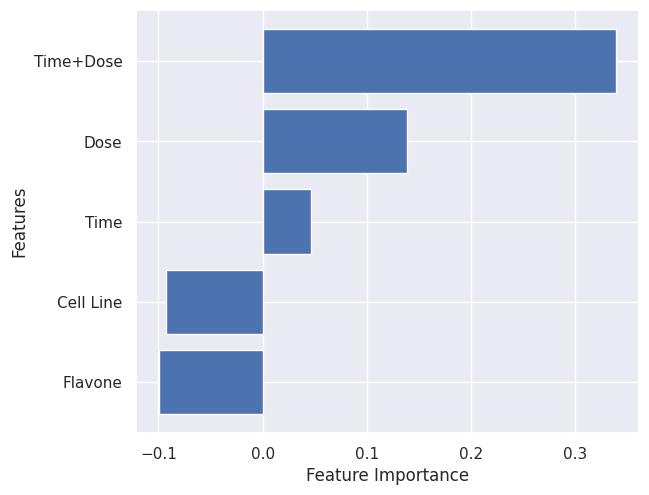

In [41]:
y_for_bar=['Flavone', 'Cell Line', 'Time', 'Dose', 'Time+Dose']

# getting values against each value of y
x_for_bar=[-0.0999766649612458, -0.09282086880527793, 0.04594956975442628, 0.1389196974171606, 0.3397373711944995]
plt.figure(figsize=(6.5, 5.5))
plt.barh(y_for_bar, x_for_bar)

# setting label of y-axis
plt.ylabel("Features")

# setting label of x-axis
plt.xlabel("Feature Importance")
#plt.title("Horizontal bar graph")
#plt.grid(axis='x')
plt.show()